In [1]:
import pandas as pd
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import contextily as cx
from matplotlib.colors import LinearSegmentedColormap

In [ ]:
def calculate_closeness_centrality(df, alpha=0.5):
    
    df_valid = df[df['next_cluster'].notna()].copy()
    df_valid['next_cluster'] = df_valid['next_cluster'].astype(int)

    edge_weights = df_valid.groupby(['cluster', 'next_cluster'])['wt_sp'].sum().reset_index()
    edge_weights.columns = ['source', 'target', 'weight']

    G = nx.DiGraph()
    
    for _, row in edge_weights.iterrows():
        weight = row['weight']
        weight_alpha = weight ** alpha
   
        distance = 1.0 / weight_alpha
        G.add_edge(int(row['source']), int(row['target']), 
                   weight=weight_alpha, distance=distance)
    
    closeness = nx.closeness_centrality(G, distance='distance')
    
    closeness_df = pd.DataFrame([
        {'cluster': node, 'closeness_centrality': cc}
        for node, cc in closeness.items()
    ]).sort_values('closeness_centrality', ascending=False)
    
    return closeness_df, G


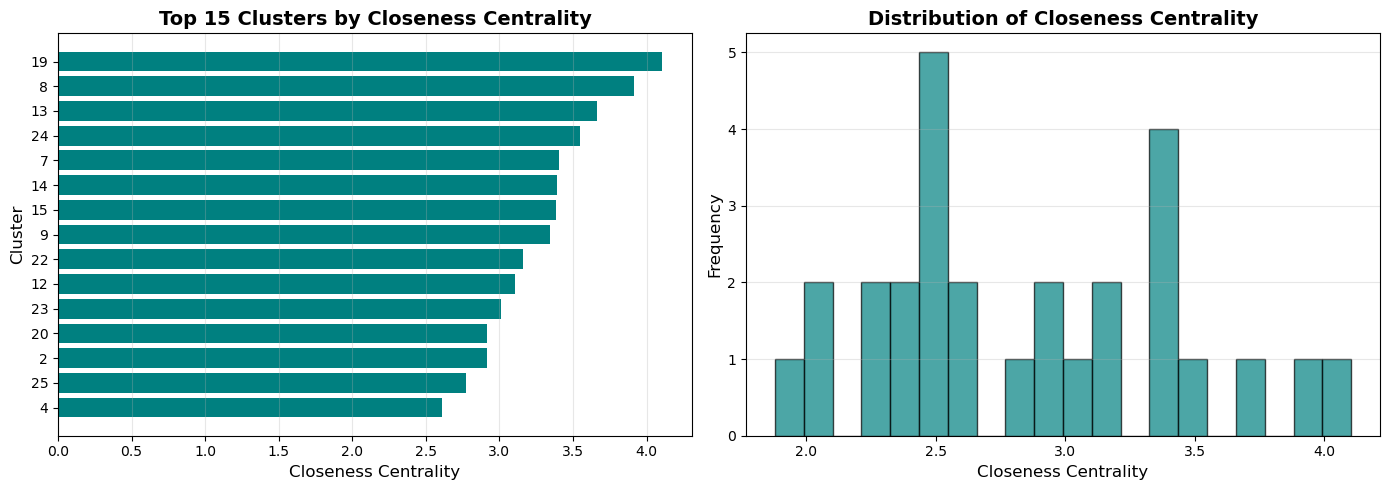

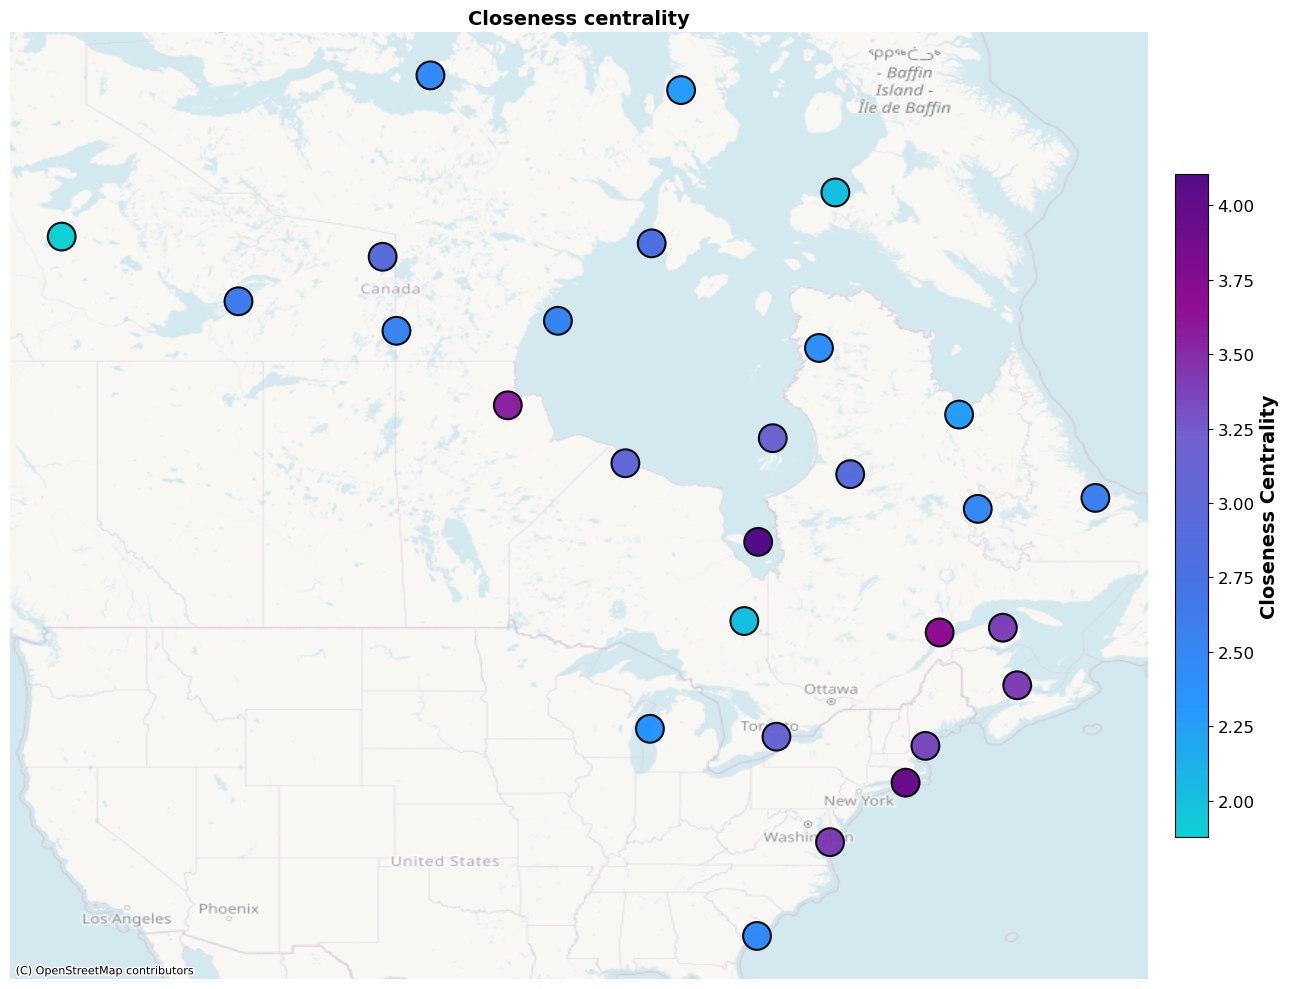

In [5]:
def plot_closeness_results(closeness_df):
   
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    ax1 = axes[0]
    top_closeness = closeness_df.head(15)
    ax1.barh(top_closeness['cluster'].astype(str), 
             top_closeness['closeness_centrality'], 
             color='teal')
    ax1.set_xlabel('Closeness Centrality', fontsize=12)
    ax1.set_ylabel('Cluster', fontsize=12)
    ax1.set_title('Top 15 Clusters by Closeness Centrality', 
                  fontsize=14, fontweight='bold')
    ax1.invert_yaxis()
    ax1.grid(axis='x', alpha=0.3)
    
    ax2 = axes[1]
    ax2.hist(closeness_df['closeness_centrality'], bins=20, 
             edgecolor='black', alpha=0.7, color='teal')
    ax2.set_xlabel('Closeness Centrality', fontsize=12)
    ax2.set_ylabel('Frequency', fontsize=12)
    ax2.set_title('Distribution of Closeness Centrality', 
                  fontsize=14, fontweight='bold')
    ax2.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.show()


def plot_closeness_map(df, closeness_df):
 
    cluster_coords = df.groupby('cluster').agg({
        'lat': 'mean',
        'lon': 'mean'
    }).reset_index()
    
    cluster_data = cluster_coords.merge(closeness_df, on='cluster')
    
    def lat_lon_to_web_mercator(lon, lat):

        x = lon * 20037508.34 / 180
        y = np.log(np.tan((90 + lat) * np.pi / 360)) / (np.pi / 180)
        y = y * 20037508.34 / 180
        return x, y
    
    x_coords = []
    y_coords = []
    for _, row in cluster_data.iterrows():
        x, y = lat_lon_to_web_mercator(row['lon'], row['lat'])
        x_coords.append(x)
        y_coords.append(y)
    
    cluster_data['x_web'] = x_coords
    cluster_data['y_web'] = y_coords
    
    fig, ax = plt.subplots(figsize=(14, 10))

    colors = ['#00CED1', '#1E90FF', '#4169E1', '#6A5ACD', '#8B008B', '#4B0082']
    cmap = LinearSegmentedColormap.from_list('closeness', colors, N=256)

    closeness_values = cluster_data['closeness_centrality']
    

    scatter = ax.scatter(
        cluster_data['x_web'],
        cluster_data['y_web'],
        c=closeness_values,
        s=400,
        cmap=cmap,
        vmin=closeness_values.min(),
        vmax=closeness_values.max(),
        edgecolors='black',
        linewidths=1.5,
        zorder=10,
        alpha=0.95
    )
    
    cx.add_basemap(ax, source=cx.providers.OpenStreetMap.Mapnik, 
                       alpha=0.5, zorder=1)

    
    cbar = plt.colorbar(scatter, ax=ax, orientation='vertical', 
                        pad=0.02, shrink=0.7, aspect=20)
    cbar.set_label('Closeness Centrality', fontsize=14, fontweight='bold')
    cbar.ax.tick_params(labelsize=12)
    
    ax.set_title(f'Closeness centrality', fontsize=14, fontweight='bold')
    ax.set_axis_off()
    
    plt.tight_layout()
    plt.show()
    
    
csv_path = "/Users/martina/Università/esami_da_fare/complex_networks/sea-duck-network/centroids_k28_definitivo.csv"

df = pd.read_csv(csv_path, sep=';')

closeness_df, G = calculate_closeness_centrality(df, alpha=0.5)

plot_closeness_results(closeness_df)

plot_closeness_map(df, closeness_df)


   ✓ Eigenvector centrality calcolata per 28 cluster


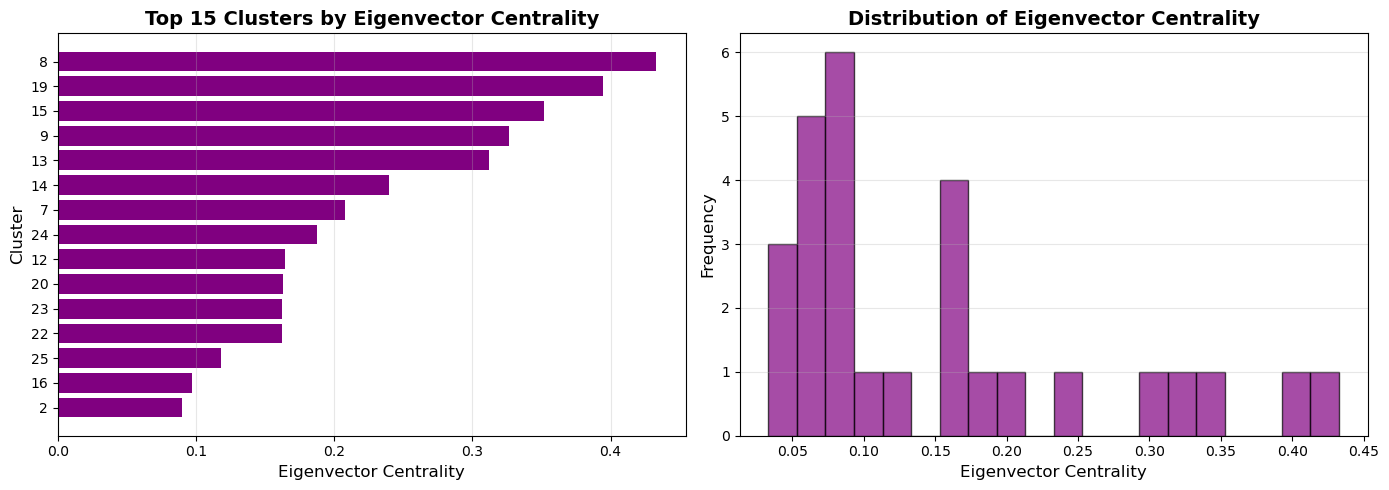

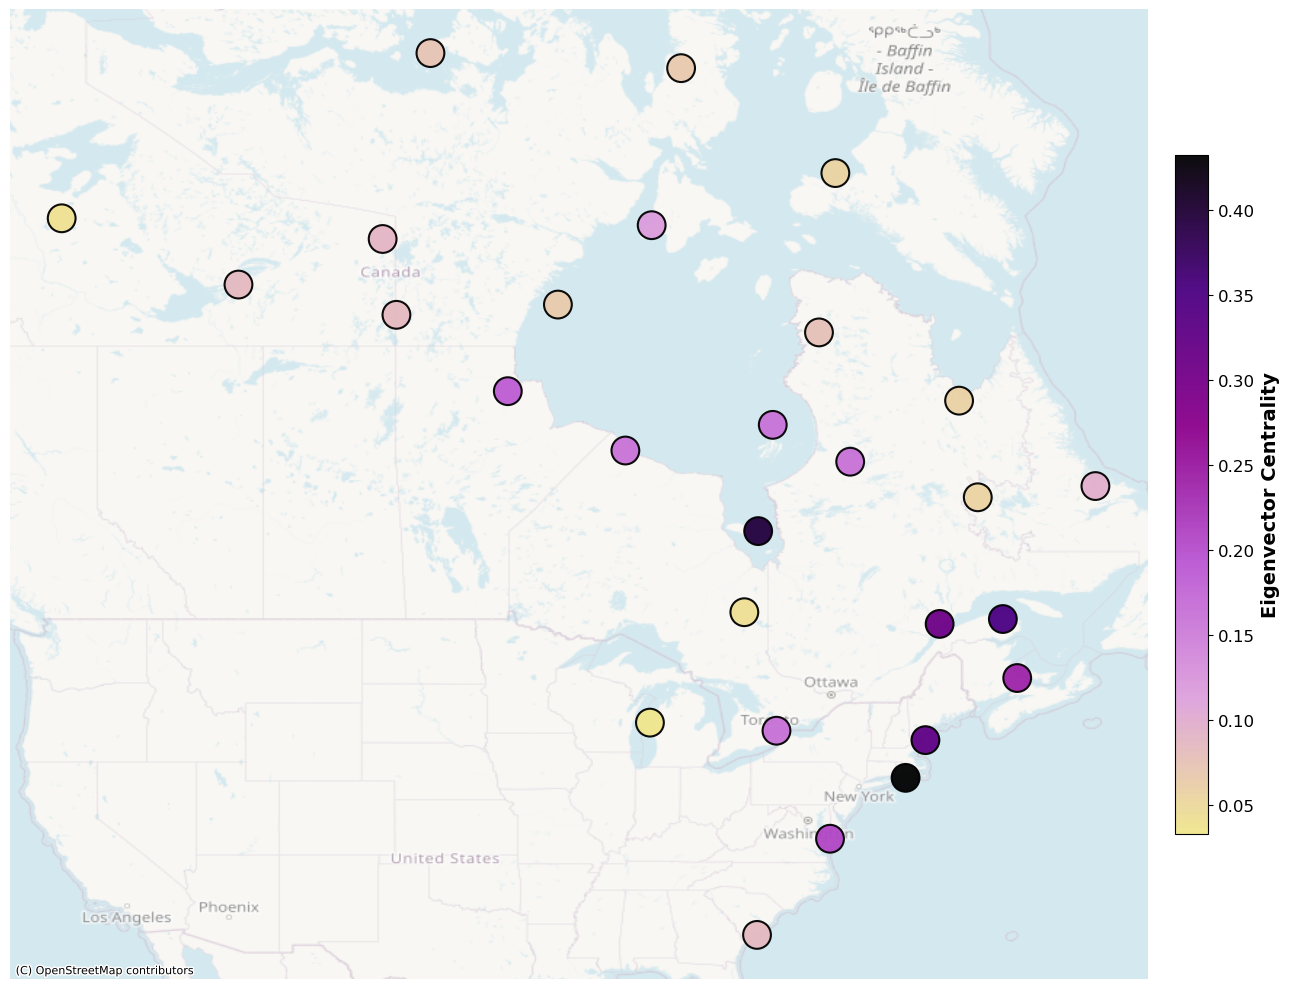

In [9]:
def calculate_eigenvector_centrality(df, alpha=0.5):

    df_valid = df[df['next_cluster'].notna()].copy()
    df_valid['next_cluster'] = df_valid['next_cluster'].astype(int)
    
    edge_weights = df_valid.groupby(['cluster', 'next_cluster'])['wt_sp'].sum().reset_index()
    edge_weights.columns = ['source', 'target', 'weight']
 
    G_directed = nx.DiGraph()
    
    for _, row in edge_weights.iterrows():
        weight = row['weight']
        weight_alpha = weight ** alpha
        G_directed.add_edge(int(row['source']), int(row['target']), 
                           weight=weight_alpha)
    
    G = G_directed.to_undirected()

    try:
        # Usa weight='weight' per considerare i pesi w^alpha
        eigenvector = nx.eigenvector_centrality(G, weight='weight', max_iter=1000)
        
        eigenvector_df = pd.DataFrame([
            {'cluster': node, 'eigenvector_centrality': ec}
            for node, ec in eigenvector.items()
        ]).sort_values('eigenvector_centrality', ascending=False)
        
        print(f"   ✓ Eigenvector centrality calcolata per {len(eigenvector_df)} cluster")
        
    except nx.PowerIterationFailedConvergence:
        print("   ⚠️ Power iteration non convergente, uso valori di default")
        eigenvector_df = pd.DataFrame([
            {'cluster': node, 'eigenvector_centrality': 0.0}
            for node in G.nodes()
        ])
    
    # 6. Stampa risultati

    return eigenvector_df, G


def plot_eigenvector_results(eigenvector_df):

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    ax1 = axes[0]
    top_eigenvector = eigenvector_df.head(15)
    ax1.barh(top_eigenvector['cluster'].astype(str), 
             top_eigenvector['eigenvector_centrality'], 
             color='purple')
    ax1.set_xlabel('Eigenvector Centrality', fontsize=12)
    ax1.set_ylabel('Cluster', fontsize=12)
    ax1.set_title('Top 15 Clusters by Eigenvector Centrality', 
                  fontsize=14, fontweight='bold')
    ax1.invert_yaxis()
    ax1.grid(axis='x', alpha=0.3)
    
    ax2 = axes[1]
    ax2.hist(eigenvector_df['eigenvector_centrality'], bins=20, 
             edgecolor='black', alpha=0.7, color='purple')
    ax2.set_xlabel('Eigenvector Centrality', fontsize=12)
    ax2.set_ylabel('Frequency', fontsize=12)
    ax2.set_title('Distribution of Eigenvector Centrality', 
                  fontsize=14, fontweight='bold')
    ax2.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.show()


def plot_eigenvector_map(df, eigenvector_df):
   
    cluster_coords = df.groupby('cluster').agg({
        'lat': 'mean',
        'lon': 'mean'
    }).reset_index()
    
    cluster_data = cluster_coords.merge(eigenvector_df, on='cluster')
    
    def lat_lon_to_web_mercator(lon, lat):
        """Converti lat/lon in Web Mercator"""
        x = lon * 20037508.34 / 180
        y = np.log(np.tan((90 + lat) * np.pi / 360)) / (np.pi / 180)
        y = y * 20037508.34 / 180
        return x, y
    
    x_coords = []
    y_coords = []
    for _, row in cluster_data.iterrows():
        x, y = lat_lon_to_web_mercator(row['lon'], row['lat'])
        x_coords.append(x)
        y_coords.append(y)
    
    cluster_data['x_web'] = x_coords
    cluster_data['y_web'] = y_coords
    
    fig, ax = plt.subplots(figsize=(14, 10))

    colors = ['#F0E68C', '#DDA0DD', '#BA55D3', '#8B008B', '#4B0082', '#000000']
    cmap = LinearSegmentedColormap.from_list('eigenvector', colors, N=256)
    
    eigenvector_values = cluster_data['eigenvector_centrality']
    
    scatter = ax.scatter(
        cluster_data['x_web'],
        cluster_data['y_web'],
        c=eigenvector_values,
        s=400,
        cmap=cmap,
        vmin=eigenvector_values.min(),
        vmax=eigenvector_values.max(),
        edgecolors='black',
        linewidths=1.5,
        zorder=10,
        alpha=0.95
    )
    
    cx.add_basemap(ax, source=cx.providers.OpenStreetMap.Mapnik, 
                       alpha=0.5, zorder=1)
    
    cbar = plt.colorbar(scatter, ax=ax, orientation='vertical', 
                        pad=0.02, shrink=0.7, aspect=20)
    cbar.set_label('Eigenvector Centrality', fontsize=14, fontweight='bold')
    cbar.ax.tick_params(labelsize=12)
  
    ax.set_axis_off()
    
    plt.tight_layout()
    plt.show()

csv_path = "/Users/martina/Università/esami_da_fare/complex_networks/sea-duck-network/centroids_k28_definitivo.csv"

df = pd.read_csv(csv_path, sep=';')

eigenvector_df, G = calculate_eigenvector_centrality(df, alpha=0.5)

plot_eigenvector_results(eigenvector_df)

plot_eigenvector_map(df, eigenvector_df)

   ✓ Movimenti validi: 2793
   ✓ Link unici nella rete: 296
   ✓ Peso minimo: 2.9402
   ✓ Peso massimo: 795.0311
   ✓ Peso medio: 45.8967
   ✓ Betweenness calcolata per 28 cluster


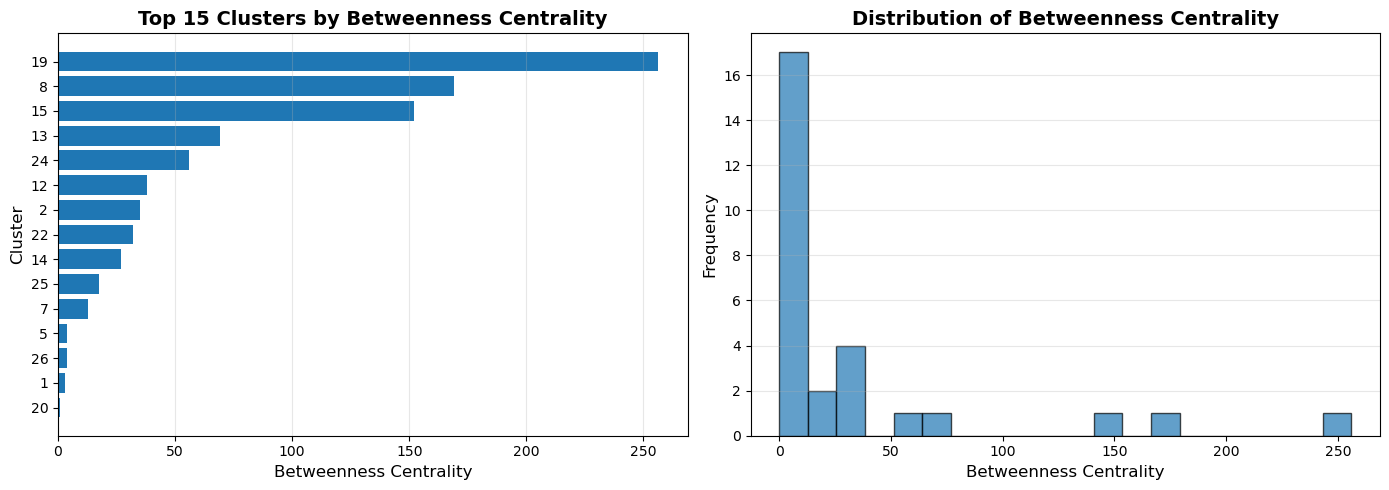

In [11]:
#Betweenness centrality globale con alpha=0.5
def calculate_global_betweenness(df, alpha=0.5):

    #Rimozione righe dove next_cluster è NaN (ultimo centroide per individuo)
    df_valid = df[df['next_cluster'].notna()].copy()
    df_valid['next_cluster'] = df_valid['next_cluster'].astype(int)
    print(f"   ✓ Movimenti validi: {len(df_valid)}")
    
    #Calcolo pesi degli archi
    edge_weights = df_valid.groupby(['cluster', 'next_cluster'])['wt_sp'].sum().reset_index()
    edge_weights.columns = ['source', 'target', 'weight']
    print(f"   ✓ Link unici nella rete: {len(edge_weights)}")
    print(f"   ✓ Peso minimo: {edge_weights['weight'].min():.4f}")
    print(f"   ✓ Peso massimo: {edge_weights['weight'].max():.4f}")
    print(f"   ✓ Peso medio: {edge_weights['weight'].mean():.4f}")
    
    G = nx.DiGraph()
    
    for _, row in edge_weights.iterrows():
        source = int(row['source'])
        target = int(row['target'])
        weight = row['weight']
        
        distance = 1.0 / (weight ** alpha)
        
        G.add_edge(source, target, weight=weight, distance=distance)
    
    #Betweenness centrality
    betweenness = nx.betweenness_centrality(
        G, 
        weight='distance',  
        normalized=False   
    )
    
    bc_df = pd.DataFrame([
        {'cluster': node, 'betweenness_centrality': bc}
        for node, bc in betweenness.items()
    ]).sort_values('betweenness_centrality', ascending=False)
    
    print(f"   ✓ Betweenness calcolata per {len(bc_df)} cluster")
    
    return bc_df, G, edge_weights

def plot_betweenness_results(bc_df, save_path=None):

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    #Plot top cluster
    ax1 = axes[0]
    top_clusters = bc_df.head(15)
    ax1.barh(top_clusters['cluster'].astype(str), top_clusters['betweenness_centrality'])
    ax1.set_xlabel('Betweenness Centrality', fontsize=12)
    ax1.set_ylabel('Cluster', fontsize=12)
    ax1.set_title('Top 15 Clusters by Betweenness Centrality', fontsize=14, fontweight='bold')
    ax1.invert_yaxis()
    ax1.grid(axis='x', alpha=0.3)
    
    #Plot distribuzione
    ax2 = axes[1]
    ax2.hist(bc_df['betweenness_centrality'], bins=20, edgecolor='black', alpha=0.7)
    ax2.set_xlabel('Betweenness Centrality', fontsize=12)
    ax2.set_ylabel('Frequency', fontsize=12)
    ax2.set_title('Distribution of Betweenness Centrality', fontsize=14, fontweight='bold')
    ax2.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    
    plt.show()


bc_df, G, edge_weights = calculate_global_betweenness(df, alpha=0.5)

base_path = "/Users/martina/Università/esami_da_fare/complex_networks/sea-duck-network/"

plot_betweenness_results(bc_df, save_path=base_path + "betweenness_global_plot.png")

edge_weights.to_csv(base_path + "edge_weights_global.csv", index=False)

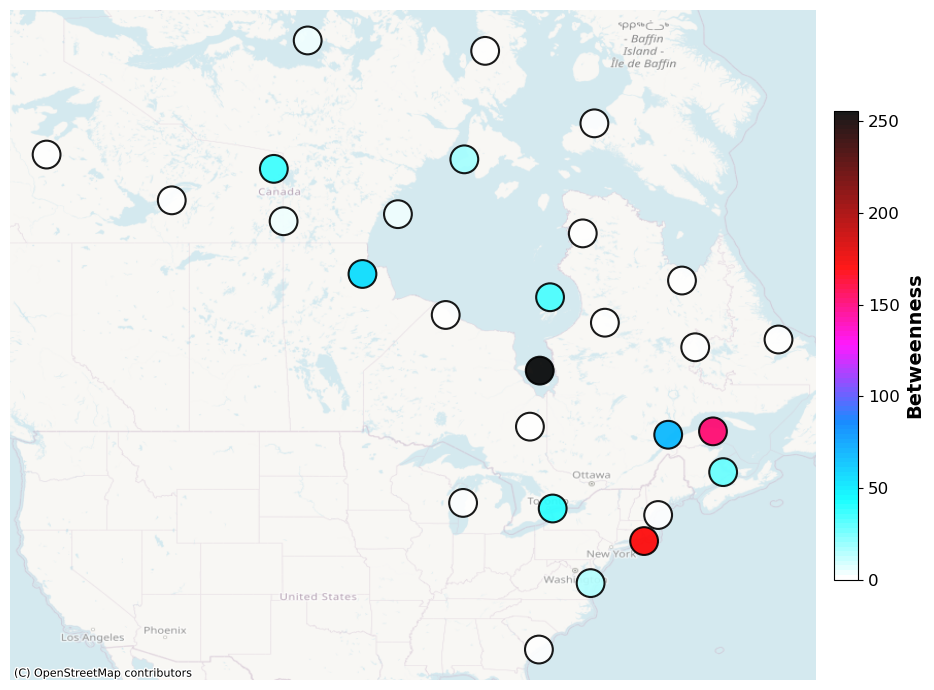

In [12]:
#Grafico nodi con betweenness centrality su mappa
def plot_betweenness_map(df, bc_df, save_path=None):
    
    cluster_coords = df.groupby('cluster').agg({
        'lat': 'mean',
        'lon': 'mean'
    }).reset_index()
    
    cluster_data = cluster_coords.merge(bc_df, on='cluster')
    
    from pyproj import Transformer
    transformer = Transformer.from_crs("EPSG:4326", "EPSG:3857", always_xy=True)
    
    x_coords, y_coords = transformer.transform(
        cluster_data['lon'].values,
        cluster_data['lat'].values
    )
    
    cluster_data['x_web'] = x_coords
    cluster_data['y_web'] = y_coords
    
    fig, ax = plt.subplots(figsize=(10,7))
    
    colors = ['#FFFFFF', '#00FFFF', '#0080FF', '#FF00FF', '#FF0000', '#800000', '#000000']
    n_bins = 100
    cmap = LinearSegmentedColormap.from_list('betweenness', colors, N=n_bins)
    
    bc_values = cluster_data['betweenness_centrality'].values
    
    scatter = ax.scatter(
        cluster_data['x_web'],
        cluster_data['y_web'],
        c=bc_values,
        s=400,
        cmap=cmap,
        vmin=0,
        vmax=bc_values.max(),
        edgecolors='black',
        linewidths=1.5,
        zorder=10,
        alpha=0.9
    )

  
    cx.add_basemap(ax, source=cx.providers.OpenStreetMap.Mapnik, alpha=0.5, zorder=1)
    
    cbar = plt.colorbar(scatter, ax=ax, orientation='vertical', 
                        pad=0.02, shrink=0.7, aspect=20)
    cbar.set_label('Betweenness', fontsize=14, fontweight='bold')
    cbar.ax.tick_params(labelsize=12)
    

    ax.set_axis_off()
    
    plt.tight_layout()
    

    plt.show()
    

base_path = "/Users/martina/Università/esami_da_fare/complex_networks/sea-duck-network/"

plot_betweenness_map(
    df=df,
    bc_df=bc_df,
    save_path=base_path + "betweenness_map_fig4c.png"
)

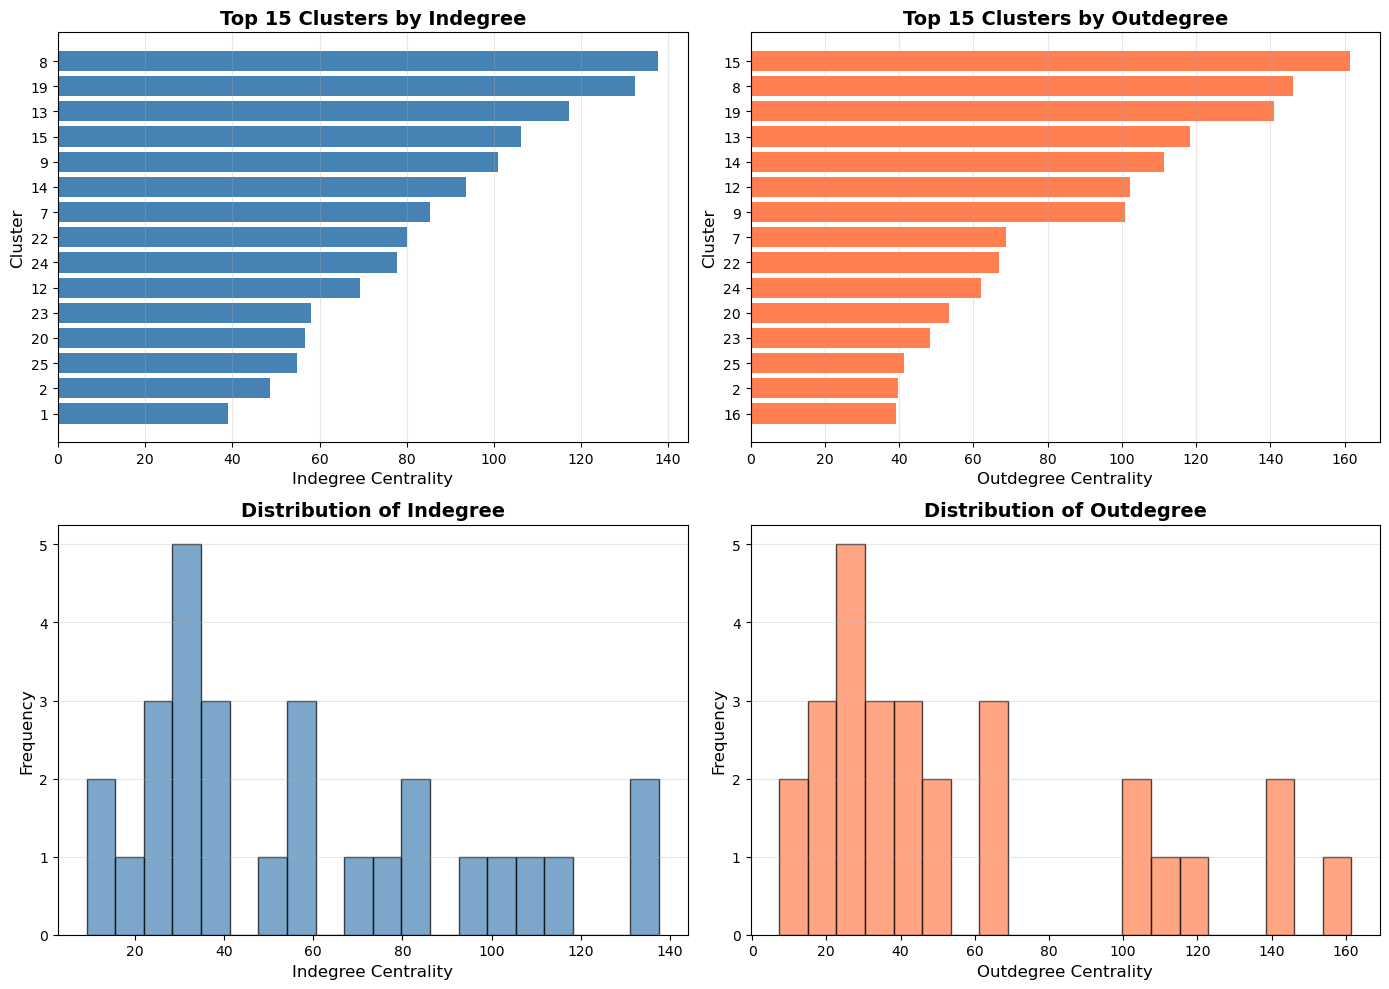

In [13]:
#Calcolo indegree e outdegree centrality
def calculate_degree_centrality(df, alpha=0.5):

    df_valid = df[df['next_cluster'].notna()].copy()
    df_valid['next_cluster'] = df_valid['next_cluster'].astype(int)
    
    edge_weights = df_valid.groupby(['cluster', 'next_cluster'])['wt_sp'].sum().reset_index()
    edge_weights.columns = ['source', 'target', 'weight']

    edge_weights['weight_alpha'] = edge_weights['weight'] ** alpha

    G = nx.DiGraph()
    
    for _, row in edge_weights.iterrows():
        G.add_edge(
            int(row['source']), 
            int(row['target']), 
            weight=row['weight'],
            weight_alpha=row['weight_alpha']
        )
    
    all_clusters = set(G.nodes())
    
    degree_data = []
    
    for cluster in all_clusters:
        #OUTDEGREE: somma dei pesi in uscita
        outdegree = sum(
            G[cluster][neighbor]['weight_alpha'] 
            for neighbor in G.successors(cluster)
        )
        
        #INDEGREE: somma dei pesi in entrata
        indegree = sum(
            G[predecessor][cluster]['weight_alpha'] 
            for predecessor in G.predecessors(cluster)
        )
        
        degree_data.append({
            'cluster': cluster,
            'indegree': indegree,
            'outdegree': outdegree,
            'total_degree': indegree + outdegree
        })
    
    degree_df = pd.DataFrame(degree_data)
    
    return degree_df, G, edge_weights


def plot_degree_centrality(degree_df, save_path=None):

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    #Plot 1: Indegree - Top 15
    ax1 = axes[0, 0]
    top_in = degree_df.nlargest(15, 'indegree')
    ax1.barh(top_in['cluster'].astype(str), top_in['indegree'], color='steelblue')
    ax1.set_xlabel('Indegree Centrality', fontsize=12)
    ax1.set_ylabel('Cluster', fontsize=12)
    ax1.set_title('Top 15 Clusters by Indegree', fontsize=14, fontweight='bold')
    ax1.invert_yaxis()
    ax1.grid(axis='x', alpha=0.3)
    
    # Plot 2: Outdegree - Top 15
    ax2 = axes[0, 1]
    top_out = degree_df.nlargest(15, 'outdegree')
    ax2.barh(top_out['cluster'].astype(str), top_out['outdegree'], color='coral')
    ax2.set_xlabel('Outdegree Centrality', fontsize=12)
    ax2.set_ylabel('Cluster', fontsize=12)
    ax2.set_title('Top 15 Clusters by Outdegree', fontsize=14, fontweight='bold')
    ax2.invert_yaxis()
    ax2.grid(axis='x', alpha=0.3)
    
    # Plot 3: Distribuzione Indegree
    ax3 = axes[1, 0]
    ax3.hist(degree_df['indegree'], bins=20, edgecolor='black', alpha=0.7, color='steelblue')
    ax3.set_xlabel('Indegree Centrality', fontsize=12)
    ax3.set_ylabel('Frequency', fontsize=12)
    ax3.set_title('Distribution of Indegree', fontsize=14, fontweight='bold')
    ax3.grid(axis='y', alpha=0.3)
    
    # Plot 4: Distribuzione Outdegree
    ax4 = axes[1, 1]
    ax4.hist(degree_df['outdegree'], bins=20, edgecolor='black', alpha=0.7, color='coral')
    ax4.set_xlabel('Outdegree Centrality', fontsize=12)
    ax4.set_ylabel('Frequency', fontsize=12)
    ax4.set_title('Distribution of Outdegree', fontsize=14, fontweight='bold')
    ax4.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    
    plt.show()


degree_df, G, edge_weights = calculate_degree_centrality(df, alpha=0.5)

base_path = "/Users/martina/Università/esami_da_fare/complex_networks/sea-duck-network/"

plot_degree_centrality(degree_df, save_path=base_path + "degree_centrality_plots.png")

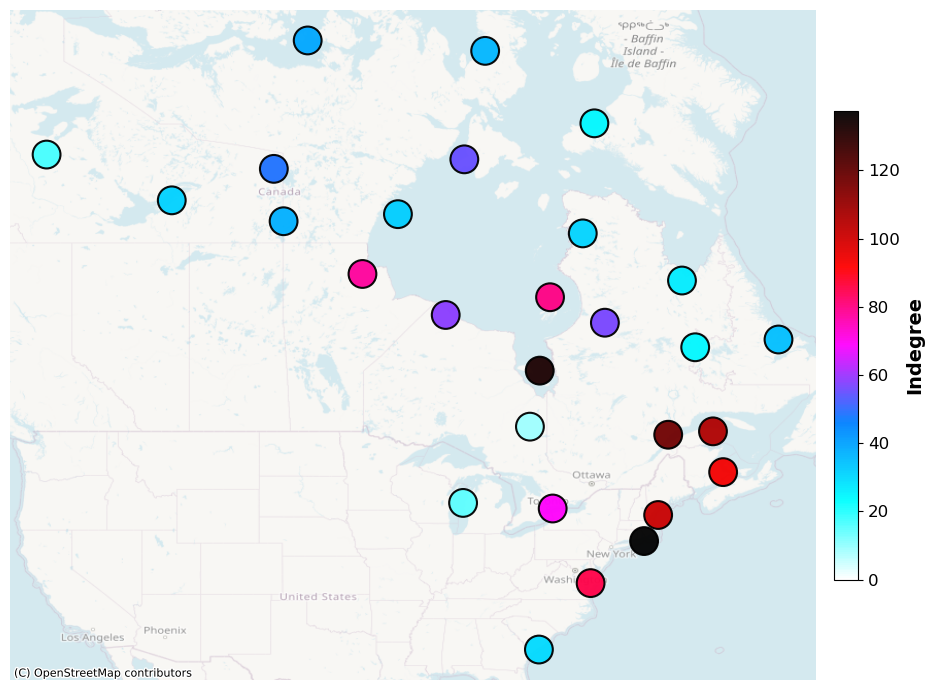

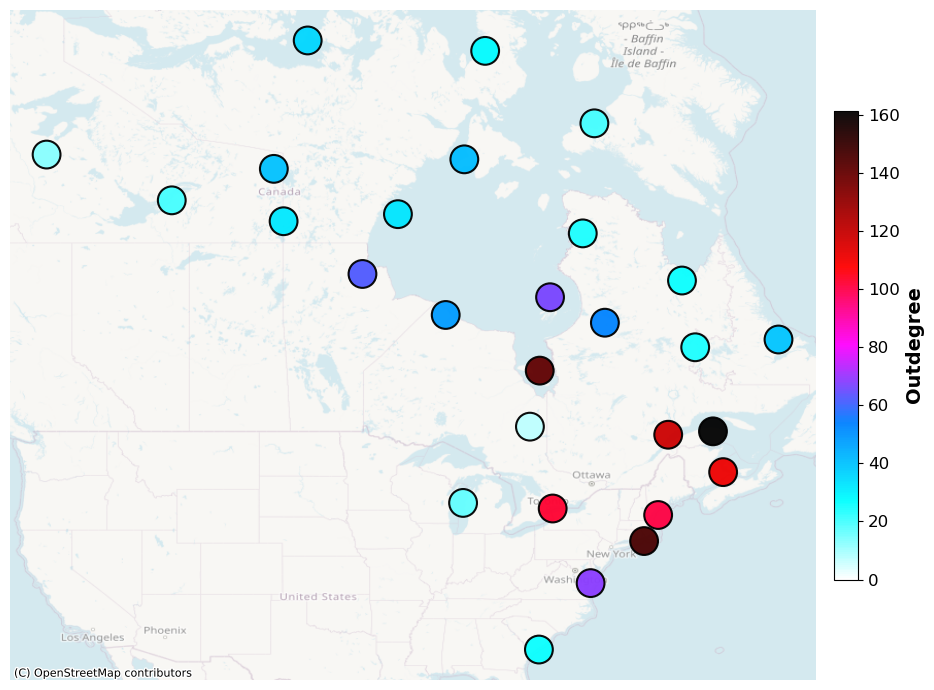

In [14]:
import matplotlib.pyplot as plt
import contextily as cx
from matplotlib.colors import LinearSegmentedColormap

#Grafico nodi con indegree e outdegree centrality su mappa
def plot_degree_map(df, degree_df, metric='indegree'):

    cluster_coords = df.groupby('cluster').agg({
        'lat': 'mean',
        'lon': 'mean'
    }).reset_index()
    
    cluster_data = cluster_coords.merge(degree_df, on='cluster')
    
    def lat_lon_to_web_mercator(lon, lat):
        x = lon * 20037508.34 / 180
        y = np.log(np.tan((90 + lat) * np.pi / 360)) / (np.pi / 180)
        y = y * 20037508.34 / 180
        return x, y
    
    x_coords = []
    y_coords = []
    for _, row in cluster_data.iterrows():
        x, y = lat_lon_to_web_mercator(row['lon'], row['lat'])
        x_coords.append(x)
        y_coords.append(y)
    
    cluster_data['x_web'] = x_coords
    cluster_data['y_web'] = y_coords
    
    fig, ax = plt.subplots(figsize=(10, 7))
    
    colors = ['#FFFFFF', '#00FFFF', '#0080FF', '#FF00FF', '#FF0000', '#800000', '#000000']
    cmap = LinearSegmentedColormap.from_list('degree', colors, N=256)
 
    values = cluster_data[metric].values
    
    scatter = ax.scatter(
        cluster_data['x_web'],
        cluster_data['y_web'],
        c=values,
        s=400,
        cmap=cmap,
        vmin=0,
        vmax=values.max(),
        edgecolors='black',
        linewidths=1.5,
        zorder=10,
        alpha=0.95
    )
    

    cx.add_basemap(ax, source=cx.providers.OpenStreetMap.Mapnik, alpha=0.5, zorder=1)
    
    cbar = plt.colorbar(scatter, ax=ax, orientation='vertical', 
                        pad=0.02, shrink=0.7, aspect=20)
    label = 'Indegree' if metric == 'indegree' else 'Outdegree'
    cbar.set_label(label, fontsize=14, fontweight='bold')
    cbar.ax.tick_params(labelsize=12)
    
    ax.set_axis_off()
    
    plt.tight_layout()
    
    plt.show()


plot_degree_map(df, degree_df, metric='indegree')

plot_degree_map(df, degree_df, metric='outdegree')

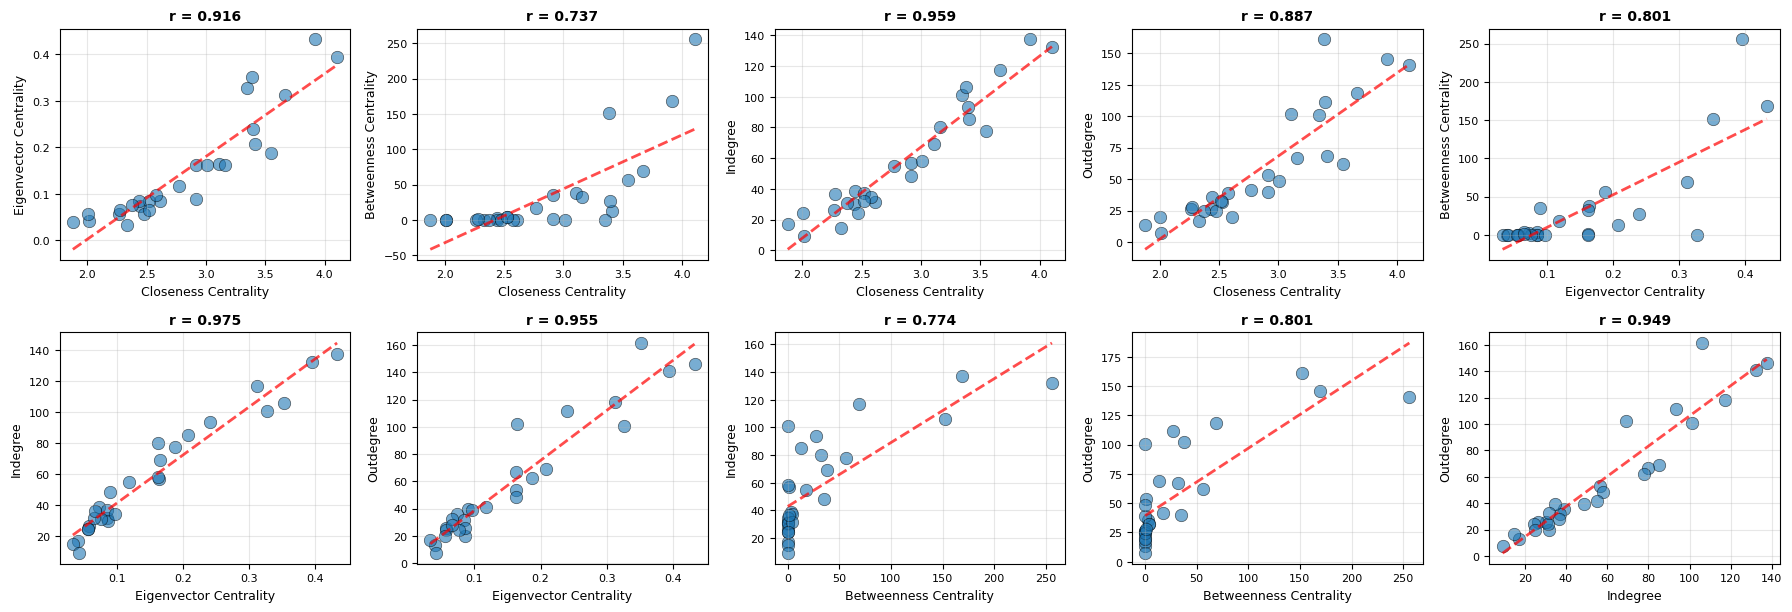

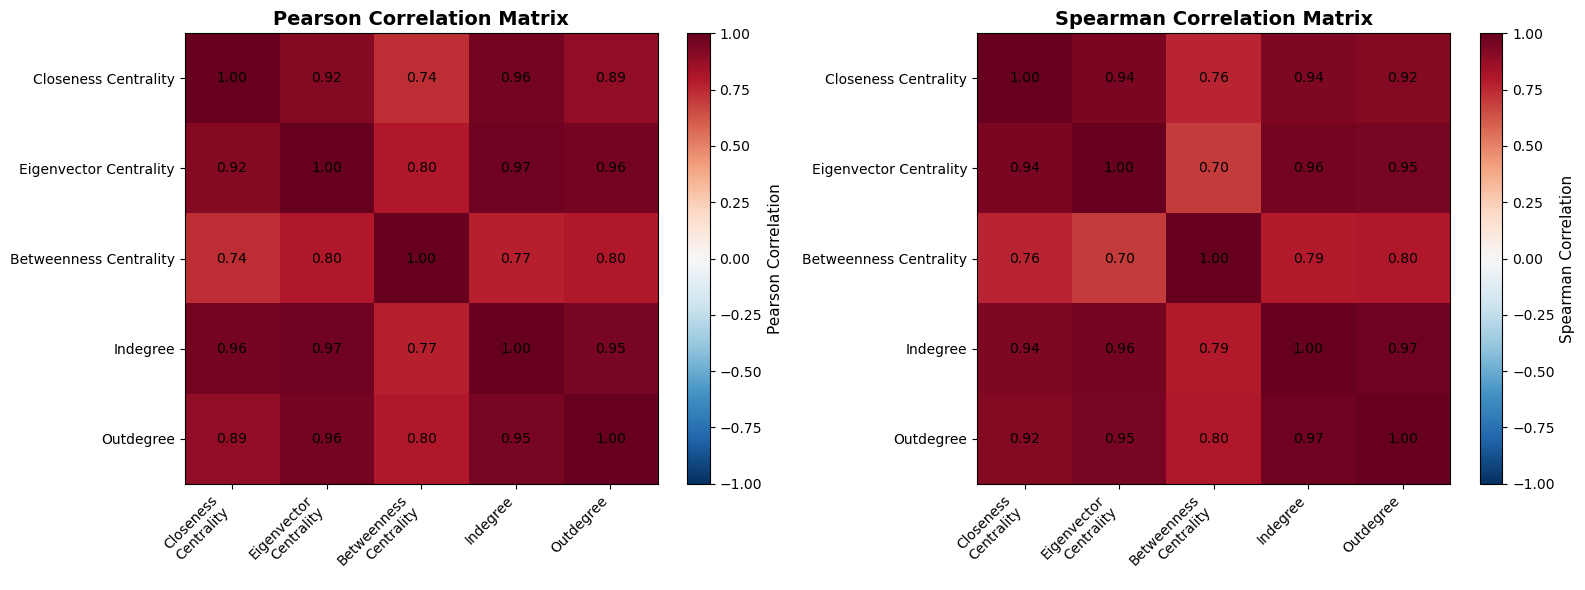

,Metric 1,Metric 2,Pearson r,Pearson p-value,Spearman ρ,Spearman p-value,R²,Slope,Intercept
5,eigenvector_centrality,indegree,0.974521,2.099238e-18,0.957307,1.563215e-15,0.949691,310.172543,10.515949
2,closeness_centrality,indegree,0.958771,1.001317e-15,0.936508,2.416688e-13,0.919243,59.319901,-110.753629
6,eigenvector_centrality,outdegree,0.955242,2.855377e-15,0.948002,1.924001e-14,0.912487,366.748121,1.964967
9,indegree,outdegree,0.949080,1.474313e-14,0.974275,2.375421e-18,0.900753,1.144842,-8.313366
0,closeness_centrality,eigenvector_centrality,0.915897,8.296524e-12,0.944171,4.743582e-14,0.838867,0.178041,-0.353537
3,closeness_centrality,outdegree,0.886816,3.326863e-10,0.920088,4.373592e-12,0.786442,66.185232,-130.214290
8,betweenness_centrality,outdegree,0.800764,3.098760e-07,0.803811,2.583724e-07,0.641223,0.576352,39.333776
4,eigenvector_centrality,betweenness_centrality,0.800680,3.114191e-07,0.700020,3.375477e-05,0.641088,427.100357,-33.213792
7,betweenness_centrality,indegree,0.773659,1.377447e-06,0.793260,4.786320e-07,0.598549,0.461627,42.929198
1,closeness_centrality,betweenness_centrality,0.737046,7.700532e-06,0.764746,2.153641e-06,0.543237,76.425629,-185.298974


In [17]:
from scipy.stats import pearsonr, spearmanr
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import seaborn as sns

def comprehensive_correlation_analysis(closeness_df, eigenvector_df, betweenness_df, 
                                       indegree_df, outdegree_df):
    
    merged = closeness_df.merge(eigenvector_df, on='cluster', how='outer')
    merged = merged.merge(betweenness_df[['cluster', 'betweenness_centrality']], on='cluster', how='outer')
    merged = merged.merge(indegree_df[['cluster', 'indegree']], on='cluster', how='outer')
    merged = merged.merge(outdegree_df[['cluster', 'outdegree']], on='cluster', how='outer')
   
    
    merged = merged.fillna(0)
    
    metrics = ['closeness_centrality', 'eigenvector_centrality', 'betweenness_centrality', 
               'indegree', 'outdegree']
    
    fig = plt.figure(figsize=(18, 18))
    
    plot_idx = 1
    for i, metric1 in enumerate(metrics):
        for j, metric2 in enumerate(metrics):
            if i < j:
                ax = plt.subplot(6, 5, plot_idx)
                plot_idx += 1
                
                x = merged[metric1].values
                y = merged[metric2].values
                
                ax.scatter(x, y, s=80, alpha=0.6, edgecolors='black', linewidths=0.5)
                
                pearson_r, pearson_p = pearsonr(x, y)
                
                if len(x) > 1:
                    X = x.reshape(-1, 1)
                    model = LinearRegression()
                    model.fit(X, y)
                    y_pred = model.predict(X)
                    
                    x_line = np.linspace(x.min(), x.max(), 100).reshape(-1, 1)
                    y_line = model.predict(x_line)
                    ax.plot(x_line, y_line, 'r--', linewidth=2, alpha=0.7)
                    
                    r2 = r2_score(y, y_pred)
                
                ax.set_xlabel(metric1.replace('_', ' ').title(), fontsize=9)
                ax.set_ylabel(metric2.replace('_', ' ').title(), fontsize=9)
                ax.set_title(f'r = {pearson_r:.3f}', fontsize=10, fontweight='bold')
                ax.grid(alpha=0.3)
                ax.tick_params(labelsize=8)
    
    plt.tight_layout()
    plt.show()
    
    corr_matrix = merged[metrics].corr(method='pearson')
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    ax1 = axes[0]
    im1 = ax1.imshow(corr_matrix, cmap='RdBu_r', aspect='auto', vmin=-1, vmax=1)
    ax1.set_xticks(range(len(metrics)))
    ax1.set_yticks(range(len(metrics)))
    ax1.set_xticklabels([m.replace('_', '\n').title() for m in metrics], rotation=45, ha='right')
    ax1.set_yticklabels([m.replace('_', ' ').title() for m in metrics])
    ax1.set_title('Pearson Correlation Matrix', fontsize=14, fontweight='bold')
    
    for i in range(len(metrics)):
        for j in range(len(metrics)):
            text = ax1.text(j, i, f'{corr_matrix.iloc[i, j]:.2f}',
                           ha="center", va="center", color="black", fontsize=10)
    
    cbar1 = plt.colorbar(im1, ax=ax1)
    cbar1.set_label('Pearson Correlation', fontsize=11)
    
    corr_matrix_spearman = merged[metrics].corr(method='spearman')
    
    ax2 = axes[1]
    im2 = ax2.imshow(corr_matrix_spearman, cmap='RdBu_r', aspect='auto', vmin=-1, vmax=1)
    ax2.set_xticks(range(len(metrics)))
    ax2.set_yticks(range(len(metrics)))
    ax2.set_xticklabels([m.replace('_', '\n').title() for m in metrics], rotation=45, ha='right')
    ax2.set_yticklabels([m.replace('_', ' ').title() for m in metrics])
    ax2.set_title('Spearman Correlation Matrix', fontsize=14, fontweight='bold')
    
    for i in range(len(metrics)):
        for j in range(len(metrics)):
            text = ax2.text(j, i, f'{corr_matrix_spearman.iloc[i, j]:.2f}',
                           ha="center", va="center", color="black", fontsize=10)
    
    cbar2 = plt.colorbar(im2, ax=ax2)
    cbar2.set_label('Spearman Correlation', fontsize=11)
    
    plt.tight_layout()
    plt.show()
    
    results = []
    for i, metric1 in enumerate(metrics):
        for j, metric2 in enumerate(metrics):
            if i < j:
                x = merged[metric1].values
                y = merged[metric2].values
                
                pearson_r, pearson_p = pearsonr(x, y)
                spearman_r, spearman_p = spearmanr(x, y)
                
                X = x.reshape(-1, 1)
                model = LinearRegression()
                model.fit(X, y)
                r2 = r2_score(y, model.predict(X))
                slope = model.coef_[0]
                intercept = model.intercept_
                
                results.append({
                    'Metric 1': metric1,
                    'Metric 2': metric2,
                    'Pearson r': pearson_r,
                    'Pearson p-value': pearson_p,
                    'Spearman ρ': spearman_r,
                    'Spearman p-value': spearman_p,
                    'R²': r2,
                    'Slope': slope,
                    'Intercept': intercept
                })
    
    results_df = pd.DataFrame(results).sort_values('Pearson r', ascending=False, key=abs)
    
    return results_df, merged


results_df, merged_data = comprehensive_correlation_analysis(
    closeness_df, eigenvector_df, bc_df, degree_df, degree_df
)

results_df